In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
import polars as pl
import adbc_driver_postgresql.dbapi as dbapi

with dbapi.connect("host=blue port=5432 dbname=bingo user=tokeiya3") as conn:
    df = pl.read_database(
        "SELECT cards,rank,SUM(round*count)::DOUBLE PRECISION/1_000_000 AS ave FROM rank_round WHERE count!=0 GROUP BY cards,rank ORDER BY rank,cards",
        connection=conn)

In [12]:
df

cards,rank,ave
i32,i32,f64
10,1,28.258596
20,1,25.162568
30,1,23.591501
40,1,22.584645
50,1,21.818286
…,…,…
190,53,0.00033
200,53,0.000388
190,54,0.000265


Text(0.5, 1.0, 'Rank Average')

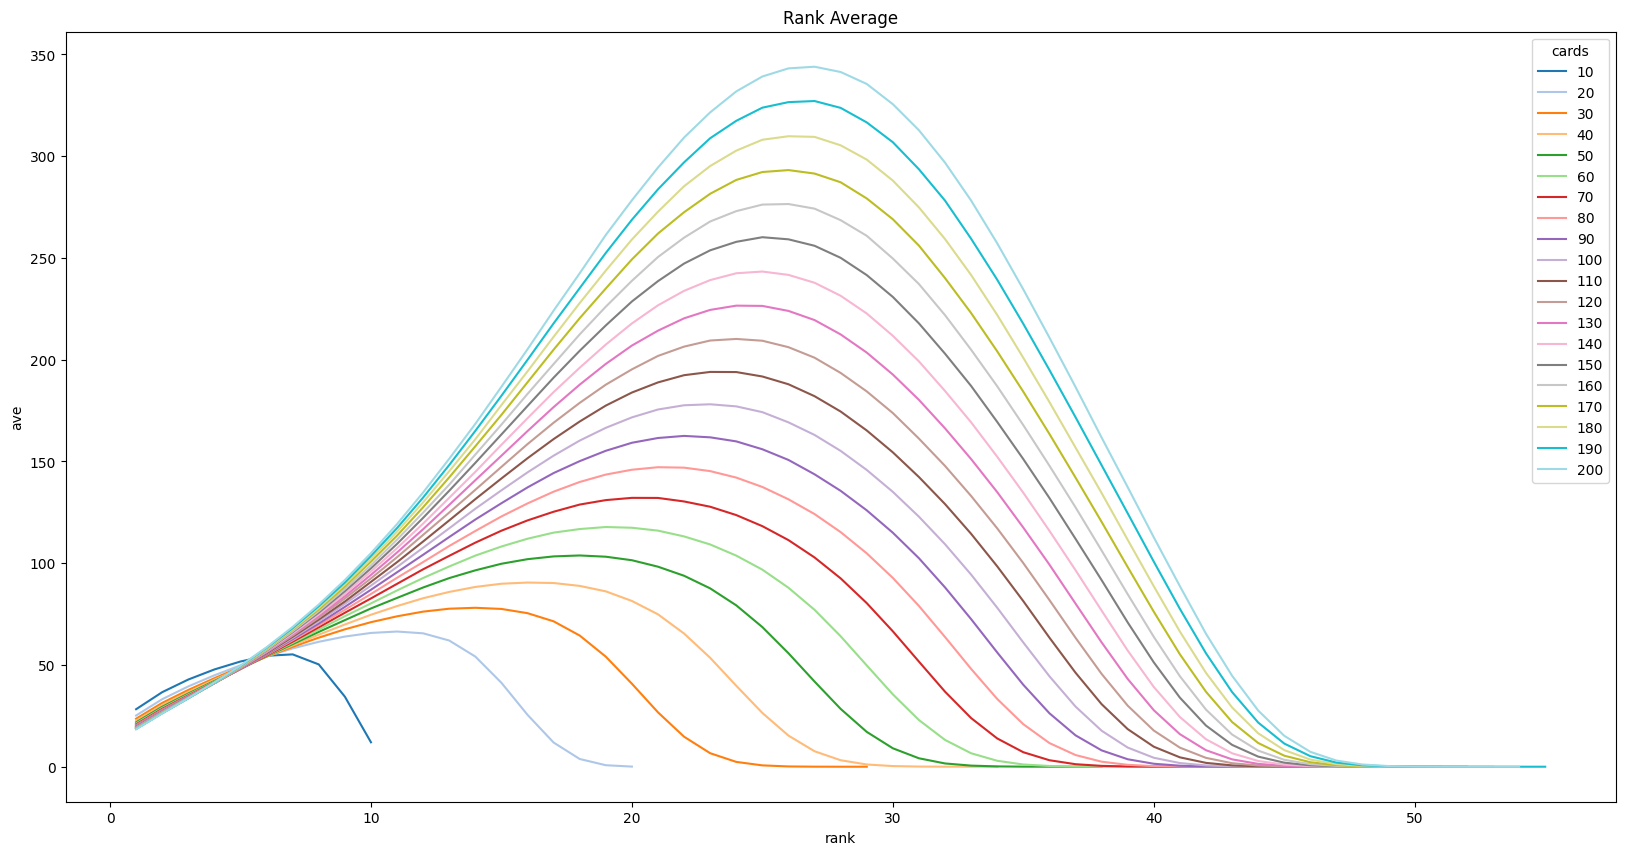

In [22]:

plt.figure(figsize=(20, 10))
ax = sns.lineplot(data=df, x="rank", y="ave", hue="cards", palette="tab20")
ax.set_title("Rank Average")